# PF6FQ Admittance Resonance Extraction

Objective: extract resonance frequencies from Ansys admittance sweeps by solving `Im(Yin)=0` for each qubit, coupling condition, and `L_jun` value.

Success criteria:

- load copied raw Q0-Q2 CSV files from `../raw/`
- export every detected admittance zero crossing
- select a qubit-like branch for each sweep point
- save publication-ready first-pass plots under `../outputs/figures/`
        


## Extraction Rule

For a one-port admittance trace `Yin(f) = G(f) + i B(f)`, an admittance resonance is detected where the susceptance crosses zero:

`B(f_r) = Im(Yin(f_r)) = 0`.

This notebook uses linear interpolation between adjacent sampled frequency points. The exported `slope_sign` distinguishes positive-slope crossings from negative-slope crossings. For the qubit-like branch in coupled traces, the selector keeps positive-slope crossings and chooses the crossing closest to the corresponding `XY`-only resonance at the same `Q` and `L_jun`.
        


In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

pd.set_option("display.max_rows", 80)
pd.set_option("display.max_columns", 30)

STUDY_DIR_CANDIDATES = [
    Path.cwd(),
    Path.cwd().parent,
    Path.cwd() / "sandbox/thesis_pf6fq_external_coupling_analysis",
]
STUDY_DIR = next(path for path in STUDY_DIR_CANDIDATES if (path / "raw").exists())
RAW_DIR = STUDY_DIR / "raw"
OUTPUT_DIR = STUDY_DIR / "outputs"
RAW_OUTPUT_DIR = OUTPUT_DIR / "raw"
TABLE_OUTPUT_DIR = OUTPUT_DIR / "tables"
FIG_DIR = OUTPUT_DIR / "figures"
for output_dir in (RAW_OUTPUT_DIR, TABLE_OUTPUT_DIR, FIG_DIR):
    output_dir.mkdir(parents=True, exist_ok=True)

FREQ_MIN_GHZ = 0.05
PLOT_FREQ_RANGE_GHZ = (3.0, 10.0)
CONDITION_ORDER = ["XY", "Readout", "XY_and_Readout"]
CONDITION_LABELS = {
    "XY": "XY only",
    "Readout": "Readout only",
    "XY_and_Readout": "XY + Readout",
}
COLORS = {
    "XY": "#2563eb",
    "Readout": "#d97706",
    "XY_and_Readout": "#059669",
}

print(f"Study directory: {STUDY_DIR}")
print(f"Raw directory exists: {RAW_DIR.exists()}")



Study directory: /Users/arfiligol/Github/superconducting-circuits-tutorial/sandbox/thesis_pf6fq_external_coupling_analysis
Raw directory exists: True


## Load Ansys Admittance CSVs

Only `*_Im_Y11.csv` files are used for admittance resonance extraction in this first pass. Q1 also has S21 files; those are left out here because they support transmission-response fitting, not one-port admittance extraction.
        


In [2]:
def infer_condition(path: Path) -> str:
    qubit = path.parent.name
    prefix = f"PF6FQ_{qubit}_"
    condition = path.stem
    if condition.startswith(prefix):
        condition = condition[len(prefix) :]
    return condition.replace("_Im_Y11", "")


def load_im_y11(path: Path) -> pd.DataFrame:
    raw = pd.read_csv(path)
    freq_col = next(col for col in raw.columns if "Freq" in col)
    l_col = next(col for col in raw.columns if "L_jun" in col)
    value_col = next(col for col in raw.columns if col not in {freq_col, l_col})
    return pd.DataFrame(
        {
            "qubit": path.parent.name,
            "condition": infer_condition(path),
            "L_jun_nH": raw[l_col].astype(float),
            "frequency_ghz": raw[freq_col].astype(float),
            "im_y": raw[value_col].astype(float),
            "source_file": path.name,
            "source_column": value_col,
        }
    )

im_y_paths = sorted(RAW_DIR.glob("Q[0-9]/*_Im_Y11.csv"))
if not im_y_paths:
    raise FileNotFoundError(f"No *_Im_Y11.csv files found under {RAW_DIR}")

trace_df = pd.concat([load_im_y11(path) for path in im_y_paths], ignore_index=True)
trace_df["condition"] = pd.Categorical(
    trace_df["condition"], categories=CONDITION_ORDER, ordered=True
)

source_summary = (
    trace_df.groupby(["qubit", "condition", "source_file"], observed=True)
    .agg(
        rows=("im_y", "size"),
        L_count=("L_jun_nH", "nunique"),
        L_min_nH=("L_jun_nH", "min"),
        L_max_nH=("L_jun_nH", "max"),
        f_min_ghz=("frequency_ghz", "min"),
        f_max_ghz=("frequency_ghz", "max"),
    )
    .reset_index()
)
display(source_summary)



,qubit,condition,source_file,rows,L_count,L_min_nH,L_max_nH,f_min_ghz,f_max_ghz
0,Q0,XY,PF6FQ_Q0_XY_Im_Y11.csv,250000,10,0.0,28.0,0.0,20.0
1,Q0,Readout,PF6FQ_Q0_Readout_Im_Y11.csv,250000,10,0.0,28.0,0.0,20.0
2,Q0,XY_and_Readout,PF6FQ_Q0_XY_and_Readout_Im_Y11.csv,250000,10,0.0,28.0,0.0,20.0
3,Q1,XY,PF6FQ_Q1_XY_Im_Y11.csv,250000,10,0.0,28.0,0.0,20.0
4,Q1,Readout,PF6FQ_Q1_Readout_Im_Y11.csv,250000,10,0.0,28.0,0.0,20.0
5,Q1,XY_and_Readout,PF6FQ_Q1_XY_and_Readout_Im_Y11.csv,250000,10,0.0,28.0,0.0,20.0
6,Q2,XY,PF6FQ_Q2_XY_Im_Y11.csv,250000,10,0.0,28.0,0.0,20.0
7,Q2,Readout,PF6FQ_Q2_Readout_Im_Y11.csv,250000,10,0.0,28.0,0.0,20.0
8,Q2,XY_and_Readout,PF6FQ_Q2_XY_and_Readout_Im_Y11.csv,250000,10,0.0,28.0,0.0,20.0


## Extract All Zero Crossings

The dense frequency grid is about 0.8 MHz, so linear interpolation is sufficient for a first-pass extraction. Frequency `0` is ignored to avoid the trivial startup value in the Ansys export.
        


In [3]:
def extract_zero_crossings(group: pd.DataFrame) -> list[dict[str, float | str]]:
    group = group.sort_values("frequency_ghz")
    freq = group["frequency_ghz"].to_numpy(dtype=float)
    im_y = group["im_y"].to_numpy(dtype=float)
    finite = np.isfinite(freq) & np.isfinite(im_y) & (freq > FREQ_MIN_GHZ)
    freq = freq[finite]
    im_y = im_y[finite]

    rows: list[dict[str, float | str]] = []
    sign = np.sign(im_y)
    crossing_indices = np.where(sign[:-1] * sign[1:] < 0)[0]
    for index in crossing_indices:
        f0 = float(freq[index])
        f1 = float(freq[index + 1])
        y0 = float(im_y[index])
        y1 = float(im_y[index + 1])
        slope = (y1 - y0) / (f1 - f0)
        frequency = f0 - y0 * (f1 - f0) / (y1 - y0)
        rows.append(
            {
                "frequency_ghz": float(frequency),
                "slope_im_y_per_ghz": float(slope),
                "slope_sign": "positive" if slope > 0 else "negative",
                "bracket_f0_ghz": f0,
                "bracket_f1_ghz": f1,
                "bracket_im_y0": y0,
                "bracket_im_y1": y1,
            }
        )
    return rows

crossing_rows: list[dict[str, float | str]] = []
for (qubit, condition, l_jun), group in trace_df.groupby(
    ["qubit", "condition", "L_jun_nH"], observed=True, sort=True
):
    for row in extract_zero_crossings(group):
        crossing_rows.append(
            {
                "qubit": str(qubit),
                "condition": str(condition),
                "L_jun_nH": float(l_jun),
                **row,
            }
        )

crossings = pd.DataFrame(crossing_rows)
if crossings.empty:
    raise RuntimeError("No admittance zero crossings were found.")

crossings["condition"] = pd.Categorical(
    crossings["condition"], categories=CONDITION_ORDER, ordered=True
)
crossings = crossings.sort_values(
    ["qubit", "condition", "L_jun_nH", "frequency_ghz"]
).reset_index(drop=True)
crossings["mode_index"] = (
    crossings.groupby(["qubit", "condition", "L_jun_nH"], observed=True).cumcount() + 1
)

all_crossings_path = RAW_OUTPUT_DIR / "all_admittance_zero_crossings.csv"
crossings.to_csv(all_crossings_path, index=False)

preview = crossings[
    crossings["frequency_ghz"].between(*PLOT_FREQ_RANGE_GHZ)
].copy()
display(preview.head(30))
print(f"Wrote {all_crossings_path}")



,qubit,condition,L_jun_nH,frequency_ghz,slope_im_y_per_ghz,slope_sign,bracket_f0_ghz,bracket_f1_ghz,bracket_im_y0,bracket_im_y1,mode_index
4,Q0,XY,5.0,9.115459,0.001376,positive,9.114765,9.115565,-9.550087e-07,1.459906e-07,1
7,Q0,XY,10.0,6.591984,0.001386,positive,6.591464,6.592264,-7.210484e-07,3.881542e-07,1
8,Q0,XY,15.0,5.424259,0.001390,positive,5.424217,5.425017,-5.847938e-08,1.053420e-06,1
9,Q0,XY,18.0,4.951333,0.001399,positive,4.950598,4.951398,-1.027550e-06,9.167199e-08,1
10,Q0,XY,20.0,4.715740,0.001392,positive,4.715389,4.716189,-4.892056e-07,6.243300e-07,1
11,Q0,XY,22.0,4.501077,0.001392,positive,4.500980,4.501780,-1.348796e-07,9.790158e-07,1
12,Q0,XY,24.0,4.301763,0.001401,positive,4.300972,4.301772,-1.107986e-06,1.254536e-08,1
13,Q0,XY,26.0,4.147190,0.001393,positive,4.146566,4.147366,-8.691287e-07,2.455590e-07,1
14,Q0,XY,28.0,3.998906,0.001394,positive,3.998560,3.999360,-4.825591e-07,6.323214e-07,1
17,Q0,Readout,5.0,6.232510,0.976416,positive,6.232249,6.233049,-2.549326e-04,5.262314e-04,1


Wrote /Users/arfiligol/Github/superconducting-circuits-tutorial/sandbox/thesis_pf6fq_external_coupling_analysis/outputs/raw/all_admittance_zero_crossings.csv


## Select The Qubit-Like Branch

The coupled traces can contain readout-line modes near 6 GHz in addition to the qubit mode. To avoid accidentally selecting a readout mode, this selector:

1. keeps positive-slope `Im(Y)=0` crossings,
2. drops `L_jun = 0 nH` from the selected branch because it is not a physical junction-inductance sweep point for the qubit branch figure,
3. uses the `XY`-only resonance as the per-qubit/per-`L_jun` reference,
4. chooses the positive-slope crossing closest to that reference.

This gives a deterministic branch for quick paper figures while preserving the full zero-crossing table above for later review.
        


In [4]:
positive_crossings = crossings[
    (crossings["slope_sign"] == "positive") & (crossings["L_jun_nH"] > 0.0)
].copy()
xy_reference = (
    positive_crossings[positive_crossings["condition"] == "XY"]
    .sort_values(["qubit", "L_jun_nH", "frequency_ghz"])
    .groupby(["qubit", "L_jun_nH"], observed=True)
    .first()[["frequency_ghz"]]
    .rename(columns={"frequency_ghz": "xy_reference_ghz"})
    .reset_index()
)
positive_crossings = positive_crossings.merge(
    xy_reference, on=["qubit", "L_jun_nH"], how="left"
)
positive_crossings["distance_to_xy_ref_mhz"] = (
    (positive_crossings["frequency_ghz"] - positive_crossings["xy_reference_ghz"]).abs() * 1000.0
)

selected_rows: list[dict[str, float | str]] = []
for (_qubit, condition, _l_jun), group in positive_crossings.groupby(
    ["qubit", "condition", "L_jun_nH"], observed=True, sort=True
):
    group = group.copy()
    if condition == "XY":
        chosen = group.sort_values("frequency_ghz").iloc[0]
        selector = "xy_only_positive_slope"
    elif group["xy_reference_ghz"].notna().any():
        chosen = group.sort_values(["distance_to_xy_ref_mhz", "frequency_ghz"]).iloc[0]
        selector = "nearest_positive_slope_to_xy_only"
    else:
        chosen = group.sort_values("frequency_ghz").iloc[0]
        selector = "lowest_positive_slope"
    row = chosen.to_dict()
    row["selector"] = selector
    selected_rows.append(row)

selected = pd.DataFrame(selected_rows)
selected["condition"] = pd.Categorical(
    selected["condition"], categories=CONDITION_ORDER, ordered=True
)
selected = selected.sort_values(["qubit", "condition", "L_jun_nH"]).reset_index(drop=True)
selected["frequency_mhz"] = selected["frequency_ghz"] * 1000.0
selected_path = RAW_OUTPUT_DIR / "selected_qubit_resonances.csv"
selected.to_csv(selected_path, index=False)

display(
    selected[
        [
            "qubit",
            "condition",
            "L_jun_nH",
            "frequency_ghz",
            "xy_reference_ghz",
            "distance_to_xy_ref_mhz",
            "selector",
        ]
    ]
)
print(f"Wrote {selected_path}")



,qubit,condition,L_jun_nH,frequency_ghz,xy_reference_ghz,distance_to_xy_ref_mhz,selector
0,Q0,XY,5.0,9.115459,9.115459,0.000000,xy_only_positive_slope
1,Q0,XY,10.0,6.591984,6.591984,0.000000,xy_only_positive_slope
2,Q0,XY,15.0,5.424259,5.424259,0.000000,xy_only_positive_slope
3,Q0,XY,18.0,4.951333,4.951333,0.000000,xy_only_positive_slope
4,Q0,XY,20.0,4.715740,4.715740,0.000000,xy_only_positive_slope
...,...,...,...,...,...,...,...
76,Q2,XY_and_Readout,20.0,4.628179,4.707998,79.818920,nearest_positive_slope_to_xy_only
77,Q2,XY_and_Readout,22.0,4.418388,4.493618,75.230484,nearest_positive_slope_to_xy_only
78,Q2,XY_and_Readout,24.0,4.234839,4.286585,51.746103,nearest_positive_slope_to_xy_only
79,Q2,XY_and_Readout,26.0,4.072057,4.140236,68.179131,nearest_positive_slope_to_xy_only


Wrote /Users/arfiligol/Github/superconducting-circuits-tutorial/sandbox/thesis_pf6fq_external_coupling_analysis/outputs/raw/selected_qubit_resonances.csv


## Optional Q0 Re(Yin) Frequency Check

The Q0 `*_Re_Yin.csv` files contain sparse frequency points with no `L_jun` column. The nearest-frequency match below is only a sanity check against the selected branch, not a source of truth for `L_jun` metadata.
        


In [5]:
def load_q0_re_yin(path: Path) -> pd.DataFrame:
    raw = pd.read_csv(path)
    freq_col = next(col for col in raw.columns if "Freq" in col)
    value_col = next(col for col in raw.columns if col != freq_col)
    condition = path.stem.replace("PF6FQ_Q0_", "").replace("_Re_Yin", "")
    return pd.DataFrame(
        {
            "qubit": "Q0",
            "condition": condition,
            "re_yin_frequency_ghz": raw[freq_col].astype(float),
            "re_yin": raw[value_col].astype(float),
            "source_file": path.name,
        }
    )

re_yin_paths = sorted((RAW_DIR / "Q0").glob("*_Re_Yin.csv"))
if re_yin_paths:
    re_yin = pd.concat([load_q0_re_yin(path) for path in re_yin_paths], ignore_index=True)
    matches = []
    for row in re_yin.itertuples(index=False):
        candidates = selected[
            (selected["qubit"] == row.qubit) & (selected["condition"].astype(str) == row.condition)
        ].copy()
        if candidates.empty:
            continue
        candidates["delta_mhz"] = (
            candidates["frequency_ghz"] - row.re_yin_frequency_ghz
        ).abs() * 1000.0
        best = candidates.sort_values("delta_mhz").iloc[0]
        matches.append(
            {
                "source_file": row.source_file,
                "condition": row.condition,
                "re_yin_frequency_ghz": row.re_yin_frequency_ghz,
                "nearest_selected_L_jun_nH": best["L_jun_nH"],
                "nearest_selected_frequency_ghz": best["frequency_ghz"],
                "delta_mhz": best["delta_mhz"],
            }
        )
    re_match = pd.DataFrame(matches).sort_values(["condition", "re_yin_frequency_ghz"])
    re_match_path = RAW_OUTPUT_DIR / "q0_re_yin_nearest_selected_match.csv"
    re_match.to_csv(re_match_path, index=False)
    display(re_match)
    print(f"Wrote {re_match_path}")
else:
    print("No Q0 Re(Yin) files found.")



,source_file,condition,re_yin_frequency_ghz,nearest_selected_L_jun_nH,nearest_selected_frequency_ghz,delta_mhz
0,PF6FQ_Q0_Readout_Re_Yin.csv,Readout,3.932701,28.0,3.932701,0.000043
1,PF6FQ_Q0_Readout_Re_Yin.csv,Readout,4.078237,26.0,4.078237,0.000177
2,PF6FQ_Q0_Readout_Re_Yin.csv,Readout,4.226728,24.0,4.226728,0.000454
3,PF6FQ_Q0_Readout_Re_Yin.csv,Readout,4.635532,20.0,4.635532,0.000321
4,PF6FQ_Q0_Readout_Re_Yin.csv,Readout,4.862014,18.0,4.862014,0.000176
5,PF6FQ_Q0_Readout_Re_Yin.csv,Readout,5.326103,15.0,5.326103,0.000336
6,PF6FQ_Q0_XY_Re_Yin.csv,XY,3.999000,28.0,3.998906,0.093776
7,PF6FQ_Q0_XY_Re_Yin.csv,XY,4.147000,26.0,4.147190,0.189652
8,PF6FQ_Q0_XY_Re_Yin.csv,XY,4.302000,24.0,4.301763,0.236886
9,PF6FQ_Q0_XY_Re_Yin.csv,XY,4.501000,22.0,4.501077,0.076914


Wrote /Users/arfiligol/Github/superconducting-circuits-tutorial/sandbox/thesis_pf6fq_external_coupling_analysis/outputs/raw/q0_re_yin_nearest_selected_match.csv


## Plot All Admittance Crossings

Circles are positive-slope crossings and x marks are negative-slope crossings. The negative-slope crossings are kept in the table because they help identify mode structure near the readout band, but they are not used for the first-pass qubit-like branch selection.
        


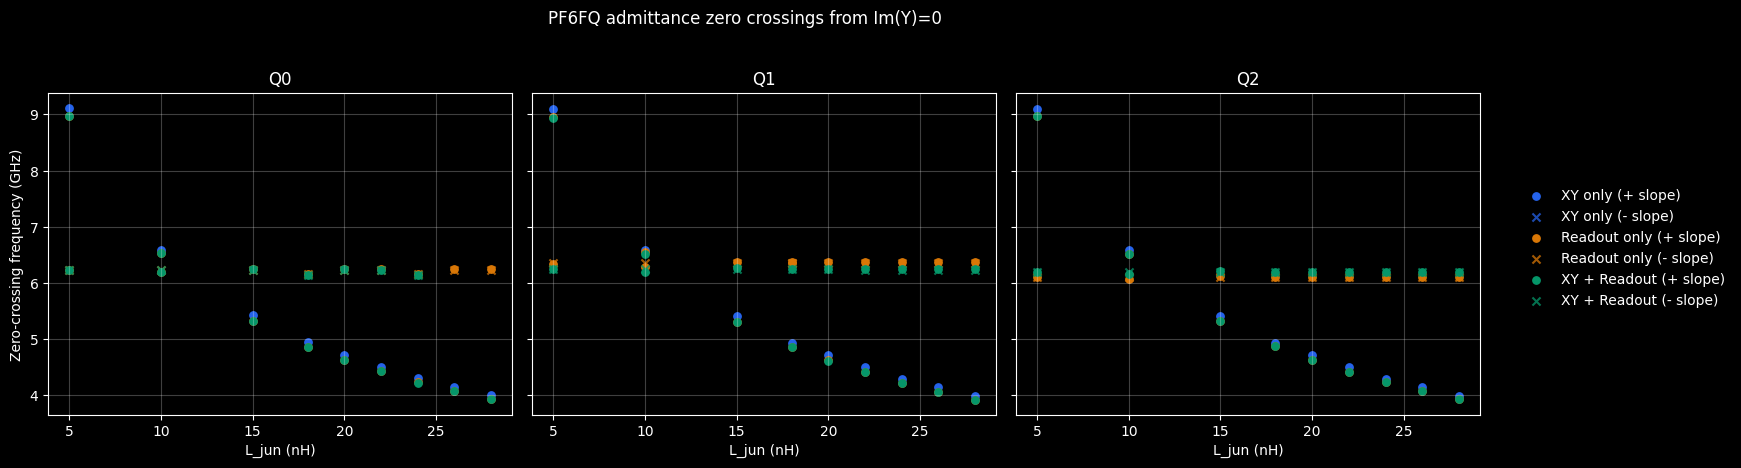

Saved /Users/arfiligol/Github/superconducting-circuits-tutorial/sandbox/thesis_pf6fq_external_coupling_analysis/outputs/figures/all_admittance_zero_crossings.png


In [6]:
plot_crossings = crossings[crossings["frequency_ghz"].between(*PLOT_FREQ_RANGE_GHZ)].copy()
qubits = sorted(plot_crossings["qubit"].unique())
fig, axes = plt.subplots(1, len(qubits), figsize=(15, 4.5), sharey=True)
if len(qubits) == 1:
    axes = [axes]

for ax, qubit in zip(axes, qubits, strict=True):
    for condition in CONDITION_ORDER:
        subset = plot_crossings[
            (plot_crossings["qubit"] == qubit)
            & (plot_crossings["condition"].astype(str) == condition)
        ]
        if subset.empty:
            continue
        positive = subset[subset["slope_sign"] == "positive"]
        negative = subset[subset["slope_sign"] == "negative"]
        ax.scatter(
            positive["L_jun_nH"],
            positive["frequency_ghz"],
            s=28,
            color=COLORS[condition],
            marker="o",
            label=f"{CONDITION_LABELS[condition]} (+ slope)",
        )
        ax.scatter(
            negative["L_jun_nH"],
            negative["frequency_ghz"],
            s=34,
            color=COLORS[condition],
            marker="x",
            alpha=0.75,
            label=f"{CONDITION_LABELS[condition]} (- slope)",
        )
    ax.set_title(qubit)
    ax.set_xlabel("L_jun (nH)")
    ax.grid(True, alpha=0.25)
axes[0].set_ylabel("Zero-crossing frequency (GHz)")
handles, labels = axes[-1].get_legend_handles_labels()
fig.legend(handles, labels, loc="center left", bbox_to_anchor=(1.01, 0.5), frameon=False)
fig.suptitle("PF6FQ admittance zero crossings from Im(Y)=0", y=1.03)
fig.tight_layout()
all_modes_fig = FIG_DIR / "all_admittance_zero_crossings.png"
fig.savefig(all_modes_fig, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved {all_modes_fig}")



## Plot Selected Qubit-Like Resonance Branch

This is the branch intended for the first paper figure: one selected positive-slope admittance resonance per qubit, condition, and `L_jun`.
        


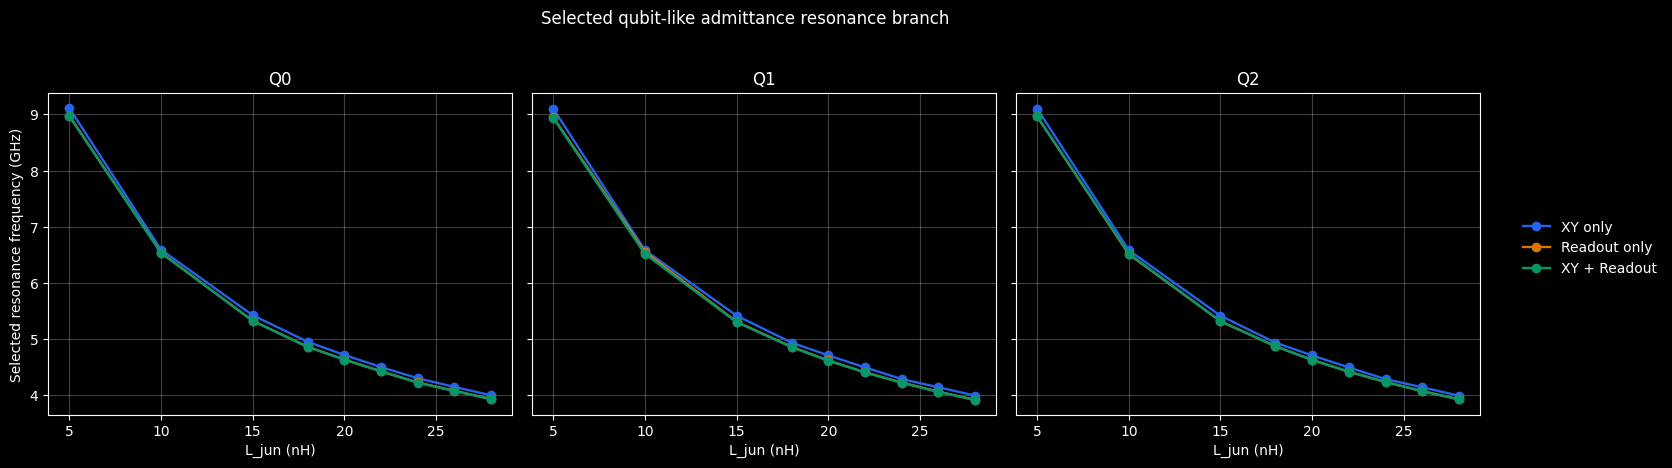

Saved /Users/arfiligol/Github/superconducting-circuits-tutorial/sandbox/thesis_pf6fq_external_coupling_analysis/outputs/figures/selected_qubit_like_resonances.png


In [ ]:
fig, axes = plt.subplots(1, len(qubits), figsize=(15, 4.5), sharey=True)
if len(qubits) == 1:
    axes = [axes]

for ax, qubit in zip(axes, qubits, strict=True):
    for condition in CONDITION_ORDER:
        subset = selected[
            (selected["qubit"] == qubit) & (selected["condition"].astype(str) == condition)
        ].sort_values("L_jun_nH")
        if subset.empty:
            continue
        ax.plot(
            subset["L_jun_nH"],
            subset["frequency_ghz"],
            marker="o",
            linewidth=1.7,
            color=COLORS[condition],
            label=CONDITION_LABELS[condition],
        )
    ax.set_title(qubit)
    ax.set_xlabel("L_jun (nH)")
    ax.grid(True, alpha=0.25)
axes[0].set_ylabel("Selected resonance frequency (GHz)")
handles, labels = axes[-1].get_legend_handles_labels()
fig.legend(handles, labels, loc="center left", bbox_to_anchor=(1.01, 0.5), frameon=False)
fig.suptitle("Selected qubit-like admittance resonance branch", y=1.03)
fig.tight_layout()
selected_fig = FIG_DIR / "selected_qubit_like_resonances.png"
fig.savefig(selected_fig, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved {selected_fig}")


## Example Trace Check At L_jun = 28 nH

The vertical black dashed line is the selected qubit-like resonance. Thin gray vertical lines are all extracted zero crossings in the displayed window.
        


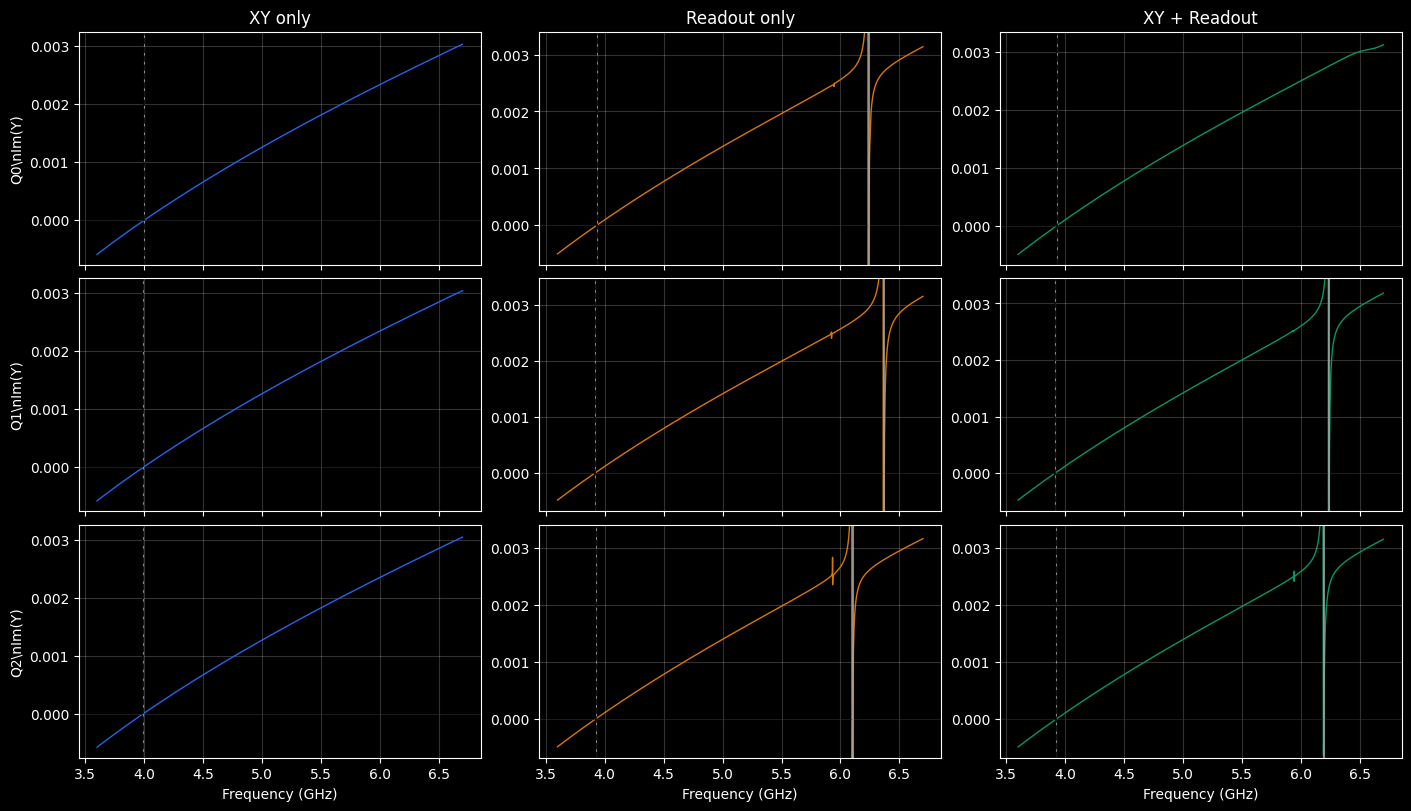

Saved /Users/arfiligol/Github/superconducting-circuits-tutorial/sandbox/thesis_pf6fq_external_coupling_analysis/outputs/figures/example_im_y_traces_L28nH.png


In [8]:
TRACE_L_NH = 28.0
TRACE_FREQ_WINDOW_GHZ = (3.6, 6.7)
fig, axes = plt.subplots(
    len(qubits), len(CONDITION_ORDER), figsize=(14, 8), sharex=True, constrained_layout=True
)

for row_index, qubit in enumerate(qubits):
    for col_index, condition in enumerate(CONDITION_ORDER):
        ax = axes[row_index, col_index]
        trace = trace_df[
            (trace_df["qubit"] == qubit)
            & (trace_df["condition"].astype(str) == condition)
            & np.isclose(trace_df["L_jun_nH"], TRACE_L_NH)
            & trace_df["frequency_ghz"].between(*TRACE_FREQ_WINDOW_GHZ)
        ].sort_values("frequency_ghz")
        if trace.empty:
            ax.set_axis_off()
            continue
        ax.plot(trace["frequency_ghz"], trace["im_y"], color=COLORS[condition], linewidth=1.0)
        ax.axhline(0.0, color="black", linewidth=0.8, alpha=0.45)
        local_crossings = crossings[
            (crossings["qubit"] == qubit)
            & (crossings["condition"].astype(str) == condition)
            & np.isclose(crossings["L_jun_nH"], TRACE_L_NH)
            & crossings["frequency_ghz"].between(*TRACE_FREQ_WINDOW_GHZ)
        ]
        for crossing in local_crossings.itertuples(index=False):
            ax.axvline(crossing.frequency_ghz, color="0.65", linewidth=0.8, alpha=0.8)
        chosen = selected[
            (selected["qubit"] == qubit)
            & (selected["condition"].astype(str) == condition)
            & np.isclose(selected["L_jun_nH"], TRACE_L_NH)
        ]
        if not chosen.empty:
            ax.axvline(
                chosen.iloc[0]["frequency_ghz"],
                color="black",
                linestyle="--",
                linewidth=1.2,
            )
        lo, hi = np.nanpercentile(trace["im_y"], [2, 98])
        if np.isfinite(lo) and np.isfinite(hi) and lo < hi:
            margin = 0.08 * (hi - lo)
            ax.set_ylim(lo - margin, hi + margin)
        if row_index == 0:
            ax.set_title(CONDITION_LABELS[condition])
        if col_index == 0:
            ax.set_ylabel(f"{qubit}\\nIm(Y)")
        if row_index == len(qubits) - 1:
            ax.set_xlabel("Frequency (GHz)")
        ax.grid(True, alpha=0.2)

trace_fig = FIG_DIR / "example_im_y_traces_L28nH.png"
fig.savefig(trace_fig, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved {trace_fig}")



## First-Pass Result Summary

Use `selected_qubit_resonances.csv` for the branch intended as the immediate paper-facing resonance-frequency table. Use `all_admittance_zero_crossings.csv` if you need to inspect mode splitting or readout-band crossings.
        


In [9]:
summary = selected.pivot_table(
    index=["qubit", "L_jun_nH"],
    columns="condition",
    values="frequency_ghz",
    aggfunc="first",
    observed=True,
).reset_index()
summary_path = TABLE_OUTPUT_DIR / "selected_qubit_resonance_summary_wide.csv"
summary.to_csv(summary_path, index=False)
display(summary)
print(f"Wrote {summary_path}")



condition,qubit,L_jun_nH,XY,Readout,XY_and_Readout
0,Q0,5.0,9.115459,8.977727,8.971077
1,Q0,10.0,6.591984,6.538352,6.533976
2,Q0,15.0,5.424259,5.326103,5.323678
3,Q0,18.0,4.951333,4.862014,4.858611
4,Q0,20.0,4.715740,4.635532,4.633628
5,Q0,22.0,4.501077,4.425274,4.423482
6,Q0,24.0,4.301763,4.226728,4.223526
7,Q0,26.0,4.147190,4.078237,4.073754
8,Q0,28.0,3.998906,3.932701,3.927758
9,Q1,5.0,9.104923,8.951178,8.939260


Wrote /Users/arfiligol/Github/superconducting-circuits-tutorial/sandbox/thesis_pf6fq_external_coupling_analysis/outputs/tables/selected_qubit_resonance_summary_wide.csv
